# Notebook for Exploratory Data Analysis
### For Analyzing Bias after Vision Zero

In [112]:
# install packages if necessary
%pip install -r "../requirements.txt"

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [113]:
import pandas as pd
import geopandas as gpd
import zipfile

### Function to load data
- Loads in police stop data from the [Stanford Opening Policing Project](https://openpolicing.stanford.edu/data/)
- Data has been cleaned in the stop preprocessing notebook 

In [114]:
def load_data(path, lat = None, long = None, geospatial = False):
    # path is the string of the path to datafile
    # lat/long are strings for the name of the latitude and longitude columns in the datafile
    # set geospatial to true if trying to extract xy coordinates from a csv file
    
    # unzip data if name ends with .zip
    if(path[-3:]=="zip"):
        with zipfile.ZipFile(path) as z:
            csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
            df = pd.read_csv(z.open(csv_file))
        print("Unzipped")
    # read in regularly for non zipped files
    else:
        # split into last file name after /
        if("geojson" in path.rsplit('/', 1)[-1]):
            df = gpd.read_file(path)
        else:
            df = pd.read_csv(path)

    # convert to a geospatial dataframe to extract x,y coordinates
    if(geospatial):
        df = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df[long], df[lat]),
            # crs set for lat/long data
            crs="EPSG:4326" 
        )

        # Print coordinate reference system to verify correct locations
        print("Data CRS:", df.crs)
    
    return df

In [115]:
stops_path = r"./data/stops_clean.csv.zip"
stops_df = load_data(stops_path)

Unzipped


In [116]:
# Recode NAs to 'None' for epc_class
stops_df['epc_class'].fillna('None')

0         None
1         High
2         None
3         None
4         None
          ... 
514771    None
514772    High
514773    None
514774    None
514775    None
Name: epc_class, Length: 514776, dtype: str

In [117]:
stops_df.head()

,Unnamed: 0,date,time,lat,lng,subject_age,subject_race,subject_sex,arrest_made,citation_issued,...,collision,motor_assist,mpc,bolo,district_left,district_right,pct_over75,pct_poc,pct_disab,epc_class
0,359092,2010-01-01,00:10:00,37.744642,-122.424567,34.0,other,female,False,True,...,0,0,0,0,INGLESIDE,INGLESIDE,0.039024,0.250610,0.056098,NaN
1,359093,2010-01-01,00:10:00,37.782744,-122.406499,22.0,other,male,False,True,...,0,0,0,0,SOUTHERN,SOUTHERN,0.032678,0.726959,0.228348,High
2,359094,2010-01-01,01:00:00,37.763301,-122.480603,27.0,asian/pacific islander,female,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.053179,0.651997,0.095762,NaN
3,359095,2010-01-01,01:00:00,37.770318,-122.452079,25.0,hispanic,female,False,False,...,0,0,0,0,PARK,PARK,0.017103,0.310707,0.075717,NaN
4,359096,2010-01-01,10:00:00,37.765696,-122.470729,36.0,white,male,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.044363,0.542523,0.034408,NaN


In [118]:
stops_df["date"] = pd.to_datetime(stops_df["date"])
stops_df["year"] = stops_df["date"].dt.year

## Race EDA

In [119]:
stops_by_year = (
    stops_df.groupby(["year", "subject_race"])
      .size()
      .reset_index(name="stops")
)

In [120]:

# SF demographic breakdown from 2010 census
population = {
    "white": 337451,
    "black": 46751,
    "asian/pacific islander": 265700 + 3128,
    "other": 28573,
    "hispanic": 121774
}
stops_by_year["population"] = stops_by_year["subject_race"].map(population)

stops_by_year["stops_per_1000"] = stops_by_year["stops"] / stops_by_year["population"] * 10000

In [121]:
stops_by_year

,year,subject_race,stops,population,stops_per_1000
0,2010,asian/pacific islander,15964,268828,593.836952
1,2010,black,16636,46751,3558.426558
2,2010,hispanic,11839,121774,972.210817
3,2010,other,11253,28573,3938.333392
4,2010,white,46972,337451,1391.965056
5,2011,asian/pacific islander,17408,268828,647.551594
6,2011,black,15921,46751,3405.488653
7,2011,hispanic,13313,121774,1093.254718
8,2011,other,9889,28573,3460.959647
9,2011,white,41910,337451,1241.958092


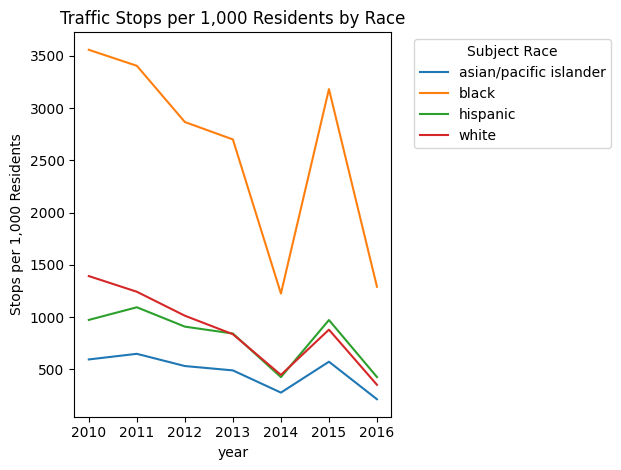

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
stops_by_year = stops_by_year[stops_by_year['subject_race'] != 'other']
sns.lineplot(
    data=stops_by_year,
    x="year",
    y="stops_per_1000",
    hue="subject_race"
)

plt.ylabel("Stops per 1,000 Residents")
plt.title("Traffic Stops per 1,000 Residents by Race")
plt.legend(title="Subject Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [123]:
citation_by_year = (
    stops_df
    .groupby(['year', 'subject_race'])
    .agg(
        total_stops=('citation_issued', 'count'),
        citations=('citation_issued', 'sum')
    )
    .reset_index()
)

citation_by_year['citation_rate'] = (
    citation_by_year['citations'] /
    citation_by_year['total_stops']
)

In [124]:
warnings_by_year = (
    stops_df
    .groupby(['year', 'subject_race'])
    .agg(
        total_stops=('warning_issued', 'count'),
        warnings=('warning_issued', 'sum')
    )
    .reset_index()
)

warnings_by_year['warning_rate'] = (
    warnings_by_year['warnings'] /
    warnings_by_year['total_stops']
)

In [125]:
citation_by_year.head()

,year,subject_race,total_stops,citations,citation_rate
0,2010,asian/pacific islander,15964,12271,0.768667
1,2010,black,16636,9489,0.570390
2,2010,hispanic,11839,8110,0.685024
3,2010,other,11253,8196,0.728339
4,2010,white,46972,32993,0.702397


In [126]:
warnings_by_year.head()

,year,subject_race,total_stops,warnings,warning_rate
0,2010,asian/pacific islander,15964,3454,0.216362
1,2010,black,16636,6361,0.382364
2,2010,hispanic,11839,3003,0.253653
3,2010,other,11253,2733,0.242869
4,2010,white,46972,12920,0.275057


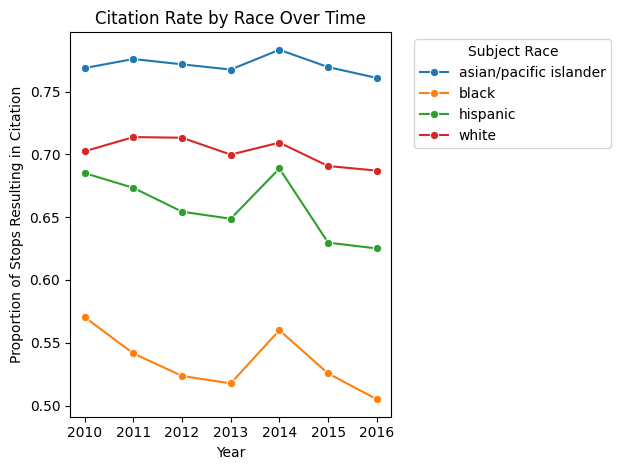

In [127]:
citation_by_year = citation_by_year[citation_by_year['subject_race'] != 'other']
sns.lineplot(
    data=citation_by_year,
    x='year',
    y='citation_rate',
    hue='subject_race',
    marker='o'
)

plt.ylabel("Proportion of Stops Resulting in Citation")
plt.xlabel("Year")
plt.title("Citation Rate by Race Over Time")

plt.legend(title="Subject Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

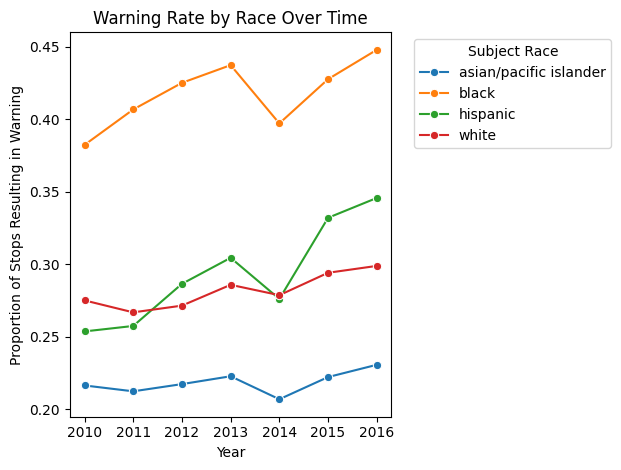

In [128]:
warnings_by_year = warnings_by_year[warnings_by_year['subject_race'] != 'other']
sns.lineplot(
    data=warnings_by_year,
    x='year',
    y='warning_rate',
    hue='subject_race',
    marker='o'
)

plt.ylabel("Proportion of Stops Resulting in Warning")
plt.xlabel("Year")
plt.title("Warning Rate by Race Over Time")

plt.legend(title="Subject Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [129]:

searches_by_year = (
    stops_df
    .groupby(['year', 'subject_race'])
    .agg(
        total_stops=('search_conducted', 'count'),
        searches=('search_conducted', 'sum')
    )
    .reset_index()
)

searches_by_year['search_rate'] = (
    searches_by_year['searches'] /
    searches_by_year['total_stops']
)

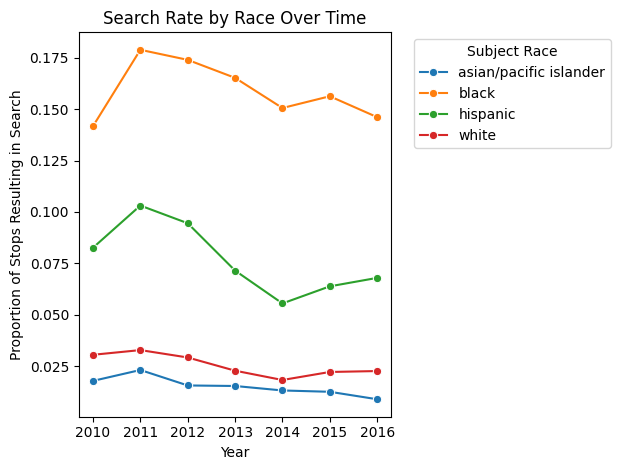

In [130]:
searches_by_year = searches_by_year[searches_by_year['subject_race'] != 'other']
sns.lineplot(
    data=searches_by_year,
    x='year',
    y='search_rate',
    hue='subject_race',
    marker='o'
)

plt.ylabel("Proportion of Stops Resulting in Search")
plt.xlabel("Year")
plt.title("Search Rate by Race Over Time")

plt.legend(title="Subject Race", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Gender EDA (Not sure if we want this but thought id do stops as proportion of pop to start)

In [131]:
stops_by_year_sex = (
    stops_df.groupby(["year", "subject_sex"])
      .size()
      .reset_index(name="stops")
)

In [132]:
population = {
   "female": 396773,
   "male": 408462
}
stops_by_year_sex["population"] = stops_by_year_sex["subject_sex"].map(population)

stops_by_year_sex["stops_per_1000"] = stops_by_year_sex["stops"] / stops_by_year_sex["population"] * 10000

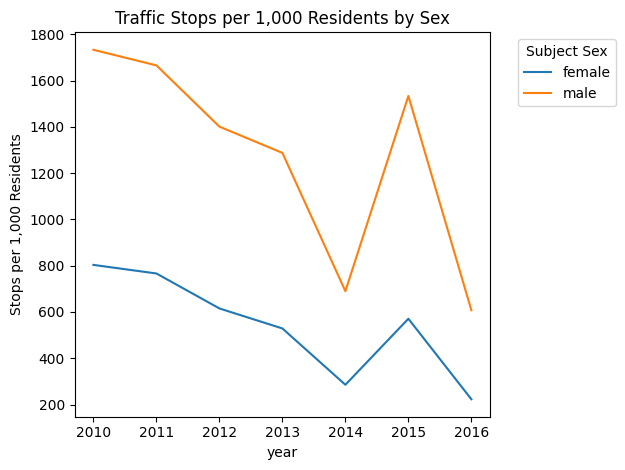

In [133]:
sns.lineplot(
    data=stops_by_year_sex,
    x="year",
    y="stops_per_1000",
    hue="subject_sex"
)

plt.ylabel("Stops per 1,000 Residents")
plt.title("Traffic Stops per 1,000 Residents by Sex")
plt.legend(title="Subject Sex", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [134]:
#march 18th 2014 is vision zero implementation date, so we can look at trends before and after that date to see if there are any changes in stop patterns.

stops_df.columns
stops_df.head()

,Unnamed: 0,date,time,lat,lng,subject_age,subject_race,subject_sex,arrest_made,citation_issued,...,motor_assist,mpc,bolo,district_left,district_right,pct_over75,pct_poc,pct_disab,epc_class,year
0,359092,2010-01-01,00:10:00,37.744642,-122.424567,34.0,other,female,False,True,...,0,0,0,INGLESIDE,INGLESIDE,0.039024,0.250610,0.056098,NaN,2010
1,359093,2010-01-01,00:10:00,37.782744,-122.406499,22.0,other,male,False,True,...,0,0,0,SOUTHERN,SOUTHERN,0.032678,0.726959,0.228348,High,2010
2,359094,2010-01-01,01:00:00,37.763301,-122.480603,27.0,asian/pacific islander,female,False,True,...,0,0,0,TARAVAL,TARAVAL,0.053179,0.651997,0.095762,NaN,2010
3,359095,2010-01-01,01:00:00,37.770318,-122.452079,25.0,hispanic,female,False,False,...,0,0,0,PARK,PARK,0.017103,0.310707,0.075717,NaN,2010
4,359096,2010-01-01,10:00:00,37.765696,-122.470729,36.0,white,male,False,True,...,0,0,0,TARAVAL,TARAVAL,0.044363,0.542523,0.034408,NaN,2010


In [135]:
stops_df.columns

Index(['Unnamed: 0', 'date', 'time', 'lat', 'lng', 'subject_age',
       'subject_race', 'subject_sex', 'arrest_made', 'citation_issued',
       'warning_issued', 'search_conducted', 'search_vehicle', 'moving',
       'mech_nonmoving', 'dui', 'collision', 'motor_assist', 'mpc', 'bolo',
       'district_left', 'district_right', 'pct_over75', 'pct_poc', 'pct_disab',
       'epc_class', 'year'],
      dtype='str')

In [136]:
stops_model = stops_df[["date","time","subject_age","subject_race","subject_sex",'citation_issued',
       'warning_issued','arrest_made', 'search_conducted', 'search_vehicle', 'moving',
       'mech_nonmoving', 'dui', 'collision', 'motor_assist','epc_class',
       'district_left', 'year']]

In [137]:
stops_model['month'] = stops_model['date'].dt.month_name()
stops_model['day_of_week'] = stops_model['date'].dt.day_name()
stops_model.head()



,date,time,subject_age,subject_race,subject_sex,citation_issued,warning_issued,arrest_made,search_conducted,search_vehicle,moving,mech_nonmoving,dui,collision,motor_assist,epc_class,district_left,year,month,day_of_week
0,2010-01-01,00:10:00,34.0,other,female,True,False,False,False,False,1,0,0,0,0,NaN,INGLESIDE,2010,January,Friday
1,2010-01-01,00:10:00,22.0,other,male,True,False,False,False,False,1,0,0,0,0,High,SOUTHERN,2010,January,Friday
2,2010-01-01,01:00:00,27.0,asian/pacific islander,female,True,False,False,False,False,1,0,0,0,0,NaN,TARAVAL,2010,January,Friday
3,2010-01-01,01:00:00,25.0,hispanic,female,False,True,False,False,False,0,1,0,0,0,NaN,PARK,2010,January,Friday
4,2010-01-01,10:00:00,36.0,white,male,True,False,False,False,False,1,0,0,0,0,NaN,TARAVAL,2010,January,Friday


In [138]:
stops_model= stops_model.rename(columns = {"district_left": "district"})

In [139]:
stops_model = pd.get_dummies(stops_model, columns=['subject_race','subject_sex','district'])
stops_model.head()

,date,time,subject_age,citation_issued,warning_issued,arrest_made,search_conducted,search_vehicle,moving,mech_nonmoving,...,district_BAYVIEW,district_CENTRAL,district_INGLESIDE,district_MISSION,district_NORTHERN,district_PARK,district_RICHMOND,district_SOUTHERN,district_TARAVAL,district_TENDERLOIN
0,2010-01-01,00:10:00,34.0,True,False,False,False,False,1,0,...,False,False,True,False,False,False,False,False,False,False
1,2010-01-01,00:10:00,22.0,True,False,False,False,False,1,0,...,False,False,False,False,False,False,False,True,False,False
2,2010-01-01,01:00:00,27.0,True,False,False,False,False,1,0,...,False,False,False,False,False,False,False,False,True,False
3,2010-01-01,01:00:00,25.0,False,True,False,False,False,0,1,...,False,False,False,False,False,True,False,False,False,False
4,2010-01-01,10:00:00,36.0,True,False,False,False,False,1,0,...,False,False,False,False,False,False,False,False,True,False


In [140]:
stops_model = pd.get_dummies(stops_model, columns=['month','day_of_week'])

In [141]:
stops_model.head()
stops_model.columns


Index(['date', 'time', 'subject_age', 'citation_issued', 'warning_issued',
       'arrest_made', 'search_conducted', 'search_vehicle', 'moving',
       'mech_nonmoving', 'dui', 'collision', 'motor_assist', 'epc_class',
       'year', 'subject_race_asian/pacific islander', 'subject_race_black',
       'subject_race_hispanic', 'subject_race_other', 'subject_race_white',
       'subject_sex_female', 'subject_sex_male', 'district_BAYVIEW',
       'district_CENTRAL', 'district_INGLESIDE', 'district_MISSION',
       'district_NORTHERN', 'district_PARK', 'district_RICHMOND',
       'district_SOUTHERN', 'district_TARAVAL', 'district_TENDERLOIN',
       'month_April', 'month_August', 'month_December', 'month_February',
       'month_January', 'month_July', 'month_June', 'month_March', 'month_May',
       'month_November', 'month_October', 'month_September',
       'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday',
       'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_wee

In [142]:
stops_model['time'] = pd.to_datetime(stops_model['time'], format='%H:%M:%S').dt.time
def categorize_time(t):
    hour = t.hour
    
    if 4 <= hour < 10:
        return 'morning'
    elif 10 <= hour < 16:
        return 'daytime'
    elif 16 <= hour < 22:
        return 'evening'
    else:
        return 'night'

stops_model['time_of_day'] = stops_model['time'].apply(categorize_time)

In [143]:
stops_model = pd.get_dummies(stops_model, columns=['time_of_day'])

In [144]:
stops_model.columns

Index(['date', 'time', 'subject_age', 'citation_issued', 'warning_issued',
       'arrest_made', 'search_conducted', 'search_vehicle', 'moving',
       'mech_nonmoving', 'dui', 'collision', 'motor_assist', 'epc_class',
       'year', 'subject_race_asian/pacific islander', 'subject_race_black',
       'subject_race_hispanic', 'subject_race_other', 'subject_race_white',
       'subject_sex_female', 'subject_sex_male', 'district_BAYVIEW',
       'district_CENTRAL', 'district_INGLESIDE', 'district_MISSION',
       'district_NORTHERN', 'district_PARK', 'district_RICHMOND',
       'district_SOUTHERN', 'district_TARAVAL', 'district_TENDERLOIN',
       'month_April', 'month_August', 'month_December', 'month_February',
       'month_January', 'month_July', 'month_June', 'month_March', 'month_May',
       'month_November', 'month_October', 'month_September',
       'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday',
       'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_wee

In [145]:
import numpy as np

stops_model['outcome'] = np.select(
    [
        stops_model['arrest_made'] == 1,
        stops_model['citation_issued'] == 1,
        stops_model['warning_issued'] == 1
    ],
    [
        'arrest',
        'citation',
        'warning'
    ],
    default='none'  
)

In [146]:
stops_model = stops_model.drop(
    columns=['warning_issued', 'citation_issued', 'arrest_made']
)

In [147]:
model_before_vision_zero = stops_model[stops_model['date'] < '2014-03-01']
model_after_vision_zero = stops_model[stops_model['date'] >= '2014-03-01']